# Download das bibliotecas utilizadas

In [ ]:
!pip install pandas numpy matplotlib geopandas pprint

# Avaliação das medianas de eficiência por diferentes categorias hospitalares

In [1]:
import pandas as pd

df1 = pd.read_pickle("../Bases/df_principal.pkl")

# Criar nova coluna 'porte' com base em 'CNES_LEITOS_SUS'
df1['porte'] = pd.cut(
    df1['CNES_LEITOS_SUS'],
    bins=[-1, 50, 150, float('inf')],  # limites das categorias
    labels=['PEQUENO', 'MÉDIO', 'GRANDE'])

sup = pd.read_pickle("../Bases/regioes_final.pkl")

sup = sup.sort_values("COMPETEN", ascending=False)

sup = sup.drop_duplicates("CNES")

sup = sup[["CNES", "Tipologia", "Eficiência"]]

df1 = df1.merge(sup, on="CNES", how="left")

df1.drop(["DESCESTAB", "Producao", "SIA_VALOR", "SIH_VALOR", "COD_IBGE", "MUNICIPIO", "NAT_JURIDICA_SIMPLIFICADA", "FAIXA_LEITOS", "CNES_LEITOS", "CNES_MEDICOS", "CNES_PROFISSIONAIS_ENFERMAGEM", "CNES_CENTROS_CIRURGICOS"], axis=1, inplace=True)


col = "Tipologia"
df1[col].fillna(df1[col].mode()[0], inplace=True)

df1["ATIVIDADE_ENSINO"] = df1["ATIVIDADE_ENSINO"].apply(lambda x: "NÃO" if x=="UNIDADE SEM ATIVIDADE DE ENSINO" else "SIM")
df1 = df1.rename(columns={"TIPO_UNIDADE": "HOSPITAL_ESPECIALIZADO"})
df1["HOSPITAL_ESPECIALIZADO"] = df1["HOSPITAL_ESPECIALIZADO"].apply(lambda x: "SIM" if x == "HOSPITAL ESPECIALIZADO" else "NÃO")
df1["FILANTROPICO"] = df1["FILANTROPICO"].apply(lambda x: "SIM" if x == "SIM" else "NÃO")
df1.drop(["NAT_JURIDICA", "SE_GERIDA_OSS", "GESTAO", "FILANTROPICO"], axis=1, inplace=True)
df1 = df1.rename(columns={"TIPO_ADMIN_PUB": "ADMIN_PUB_DIRETA"})
df1["ADMIN_PUB_DIRETA"] = df1["ADMIN_PUB_DIRETA"].apply(lambda x: "DIRETA" if x=="DIRETA" else "OUTRO")
df1.drop(["UF", "ADMIN_PUB_DIRETA"], axis=1, inplace=True)

# Identificar a moda da coluna
mode_value = df1['ESFERA_FEDERATIVA'].mode()[0]

# Substituir "OUTROS" pela moda inplace
df1['ESFERA_FEDERATIVA'].replace('OUTROS', mode_value, inplace=True)

col = "ESFERA_FEDERATIVA"
df1[col].fillna(df1[col].mode()[0], inplace=True)

df1["Tipologia"] = df1["Tipologia"].apply(lambda x: "URBANO" if x == "URBANO" else "RURAL")


colunas_cortes = ["ATIVIDADE_ENSINO", "HOSPITAL_ESPECIALIZADO", 
                  "ESFERA_FEDERATIVA", "Tipologia", "REGIAO", "porte"]

# Dicionário para armazenar os resultados
medianas_por_corte = {}

print(df1["Eficiência"].median())

for col in colunas_cortes:
    medianas = df1.groupby(col)["Eficiência"].median().sort_values(ascending=False)
    medianas_por_corte[col] = medianas
    print(f"\nMediana por {col}:")
    print(medianas)

C:\Users\User\AppData\Local\Temp\ipykernel_9996\1575107902.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].fillna(df1[col].mode()[0], inplace=True)


0.766398345130376

Mediana por ATIVIDADE_ENSINO:
ATIVIDADE_ENSINO
SIM    0.788968
NÃO    0.763812
Name: Eficiência, dtype: float64

Mediana por HOSPITAL_ESPECIALIZADO:
HOSPITAL_ESPECIALIZADO
NÃO    0.767400
SIM    0.746984
Name: Eficiência, dtype: float64

Mediana por ESFERA_FEDERATIVA:
ESFERA_FEDERATIVA
ESTADUAL     0.795649
FEDERAL      0.770915
MUNICIPAL    0.756971
Name: Eficiência, dtype: float64

Mediana por Tipologia:
Tipologia
URBANO    0.789559
RURAL     0.742764
Name: Eficiência, dtype: float64

Mediana por REGIAO:
REGIAO
NORTE           0.809087
SUDESTE         0.800290
CENTRO-OESTE    0.789430
NORDESTE        0.745787
SUL             0.708744
Name: Eficiência, dtype: float64

Mediana por porte:
porte
GRANDE     0.832621
MÉDIO      0.767398
PEQUENO    0.751000
Name: Eficiência, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_9996\1575107902.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['ESFERA_FEDERATIVA'].replace('OUTROS', mode_value, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_9996\1575107902.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

# Calcular variação da eficiência entre último e primeiro período e mediana da eficiência por região de saúde

In [2]:
import pandas as pd

df2 = pd.read_pickle("../Bases/regioes_final.pkl")

# Converter coluna para datetime
df2["COMPETEN"] = pd.to_datetime(df1["COMPETEN"], format="%Y%m")

# Ordenar por CNES e COMPETEN
df2_sorted = df2.sort_values(["CNES", "COMPETEN"])

# Selecionar a eficiência inicial e final de cada CNES
ef_final_inicial = df2_sorted.groupby("CNES")["Eficiência"].agg(
    Ef_inicial="first",
    Ef_final="last"
).reset_index()

# Calcular a variação percentual
ef_final_inicial["Var_Ef_percent"] = (ef_final_inicial["Ef_final"] / ef_final_inicial["Ef_inicial"] - 1) * 100

# Merge de volta no df1 se quiser manter essa coluna para cada CNES
df1 = df2.merge(ef_final_inicial[["CNES", "Var_Ef_percent"]], on="CNES", how="left")

# Visualizar
df1[["CNES", "Eficiência", "Var_Ef_percent"]].head(10)

,CNES,Eficiência,Var_Ef_percent
0,0000035,0.624407,22.249172
1,0000035,0.624384,22.249172
2,0000035,0.684331,22.249172
3,0000035,0.681894,22.249172
4,0000035,0.688043,22.249172
5,0000035,0.583358,22.249172
6,0000035,0.599329,22.249172
7,0000094,1.000000,11.904911
8,0000094,1.000000,11.904911
9,0000094,0.962891,11.904911


# Ler base de dados

In [3]:
import pandas as pd

df = pd.read_parquet("../Bases/results_malmquist_corrigido.parquet")
df

,MI,E1,E2,T1,T2,S1,S2,S3,CNES,cluster,periodo_t,periodo_t1
0,0.972665,0.930371,0.930815,1.045459,1.044899,0.999523,1.000059,1.000536,0017779,0,201906,201907
1,1.023176,1.059869,1.059869,0.965379,0.965379,1.000000,1.000000,1.000000,0026417,0,201906,201907
2,1.119517,1.159665,1.158703,0.965379,0.966181,1.000831,1.000000,0.999170,2000083,0,201906,201907
3,1.152954,1.105880,1.092186,1.042567,1.037946,1.012538,1.017046,1.004452,2000997,0,201906,201907
4,1.233153,1.187216,1.246424,1.038693,1.044951,0.952498,0.946793,0.994011,2008858,0,201906,201907
...,...,...,...,...,...,...,...,...,...,...,...,...
131416,0.866309,0.848703,0.882395,1.020745,0.978414,0.961817,1.003430,1.043265,8004218,8,202402,202403
131417,0.987433,0.960255,0.987326,1.028303,1.000329,0.972581,0.999779,1.027965,9131922,8,202402,202403
131418,0.566578,0.549902,0.546161,1.030326,1.036005,1.006849,1.001330,0.994519,9297715,8,202402,202403
131419,1.043195,1.013994,1.000000,1.028798,NaN,1.013994,NaN,NaN,9515925,8,202402,202403


In [7]:
# Deixar nomes das colunas mais intuitivos e selecionar índices de interesse
df.drop(["E2", "T2", "S1", "S2", "S3"], axis=1, inplace=True)
df = df.rename(columns={"E1": "catch_up", "T1": "frontier_shift"})
df

,MI,catch_up,frontier_shift,CNES,cluster,periodo_t,periodo_t1
0,0.972665,0.930371,1.045459,0017779,0,201906,201907
1,1.023176,1.059869,0.965379,0026417,0,201906,201907
2,1.119517,1.159665,0.965379,2000083,0,201906,201907
3,1.152954,1.105880,1.042567,2000997,0,201906,201907
4,1.233153,1.187216,1.038693,2008858,0,201906,201907
...,...,...,...,...,...,...,...
131416,0.866309,0.848703,1.020745,8004218,8,202402,202403
131417,0.987433,0.960255,1.028303,9131922,8,202402,202403
131418,0.566578,0.549902,1.030326,9297715,8,202402,202403
131419,1.043195,1.013994,1.028798,9515925,8,202402,202403


In [8]:
import pandas as pd
import numpy as np

# Medianas acumuladas
medianas = df[["MI", "catch_up", "frontier_shift"]].median()

# Converter para variação percentual e formatar
variacao_percentual = medianas.map(lambda x: f"{(x - 1) * 100:.2f}%")

print(variacao_percentual)

MI                0.09%
catch_up          0.00%
frontier_shift    0.26%
dtype: object


# Verificar a influência da pandemia

In [9]:
df2 = pd.read_pickle("../Bases/df_principal.pkl")
df2 = df2.drop_duplicates(subset=["CNES"])
df = df.merge(df2[["CNES", "REGIAO"]], on="CNES", how="left")
df

,MI,catch_up,frontier_shift,CNES,cluster,periodo_t,periodo_t1,REGIAO
0,0.972665,0.930371,1.045459,0017779,0,201906,201907,SUL
1,1.023176,1.059869,0.965379,0026417,0,201906,201907,SUDESTE
2,1.119517,1.159665,0.965379,2000083,0,201906,201907,NORTE
3,1.152954,1.105880,1.042567,2000997,0,201906,201907,NORTE
4,1.233153,1.187216,1.038693,2008858,0,201906,201907,NORDESTE
...,...,...,...,...,...,...,...,...
131416,0.866309,0.848703,1.020745,8004218,8,202402,202403,NORDESTE
131417,0.987433,0.960255,1.028303,9131922,8,202402,202403,NORDESTE
131418,0.566578,0.549902,1.030326,9297715,8,202402,202403,SUDESTE
131419,1.043195,1.013994,1.028798,9515925,8,202402,202403,NORDESTE


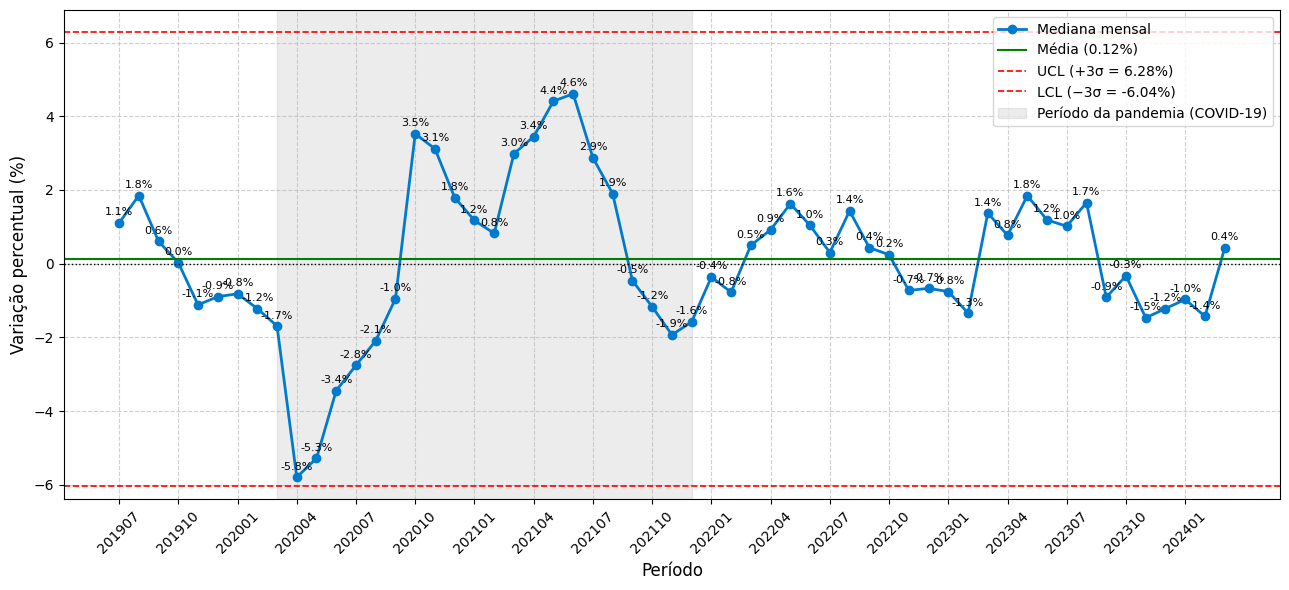

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular as medianas percentuais
medianas = (df.groupby("periodo_t1")["MI"].median() - 1) * 100

# Média e limites de controle (3σ)
media = medianas.mean()
desvio = medianas.std()
ucl = media + 3 * desvio
lcl = media - 3 * desvio

# Figura
plt.figure(figsize=(13, 6))
plt.plot(medianas.index, medianas.values, marker='o', color='#007acc', linewidth=2, label='Mediana mensal')

# Adicionar rótulos nas bolinhas
for x, y in zip(medianas.index, medianas.values):
    plt.text(x, y + 0.15, f"{y:.1f}%", ha='center', va='bottom', fontsize=8, color='black')

# Adicionar linha de média e limites
plt.axhline(media, color='green', linestyle='-', linewidth=1.5, label=f'Média ({media:.2f}%)')
plt.axhline(ucl, color='red', linestyle='--', linewidth=1.2, label=f'UCL (+3σ = {ucl:.2f}%)')
plt.axhline(lcl, color='red', linestyle='--', linewidth=1.2, label=f'LCL (−3σ = {lcl:.2f}%)')

# Linha de referência em 0%
plt.axhline(0, color='black', linestyle=':', linewidth=1)

# Sombreado da pandemia (mar/2020 a dez/2021)
pandemia_inicio = "202003"
pandemia_fim = "202112"
idx_inicio = medianas.index.get_loc(pandemia_inicio)
idx_fim = medianas.index.get_loc(pandemia_fim)
plt.axvspan(idx_inicio, idx_fim, color='gray', alpha=0.15, label='Período da pandemia (COVID-19)')

# Mostrar apenas alguns meses no eixo x
step = 3
xticks = np.arange(0, len(medianas.index), step)
xticklabels = [medianas.index[i] for i in xticks]
plt.xticks(xticks, xticklabels, rotation=45, fontsize=10)

# Estética geral do gráfico
plt.xlabel("Período", fontsize=12)
plt.ylabel("Variação percentual (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig("../Figuras/evolucao_mensal_mpi.png", dpi=300)

plt.show()

# Influência da pandemia por região brasileira

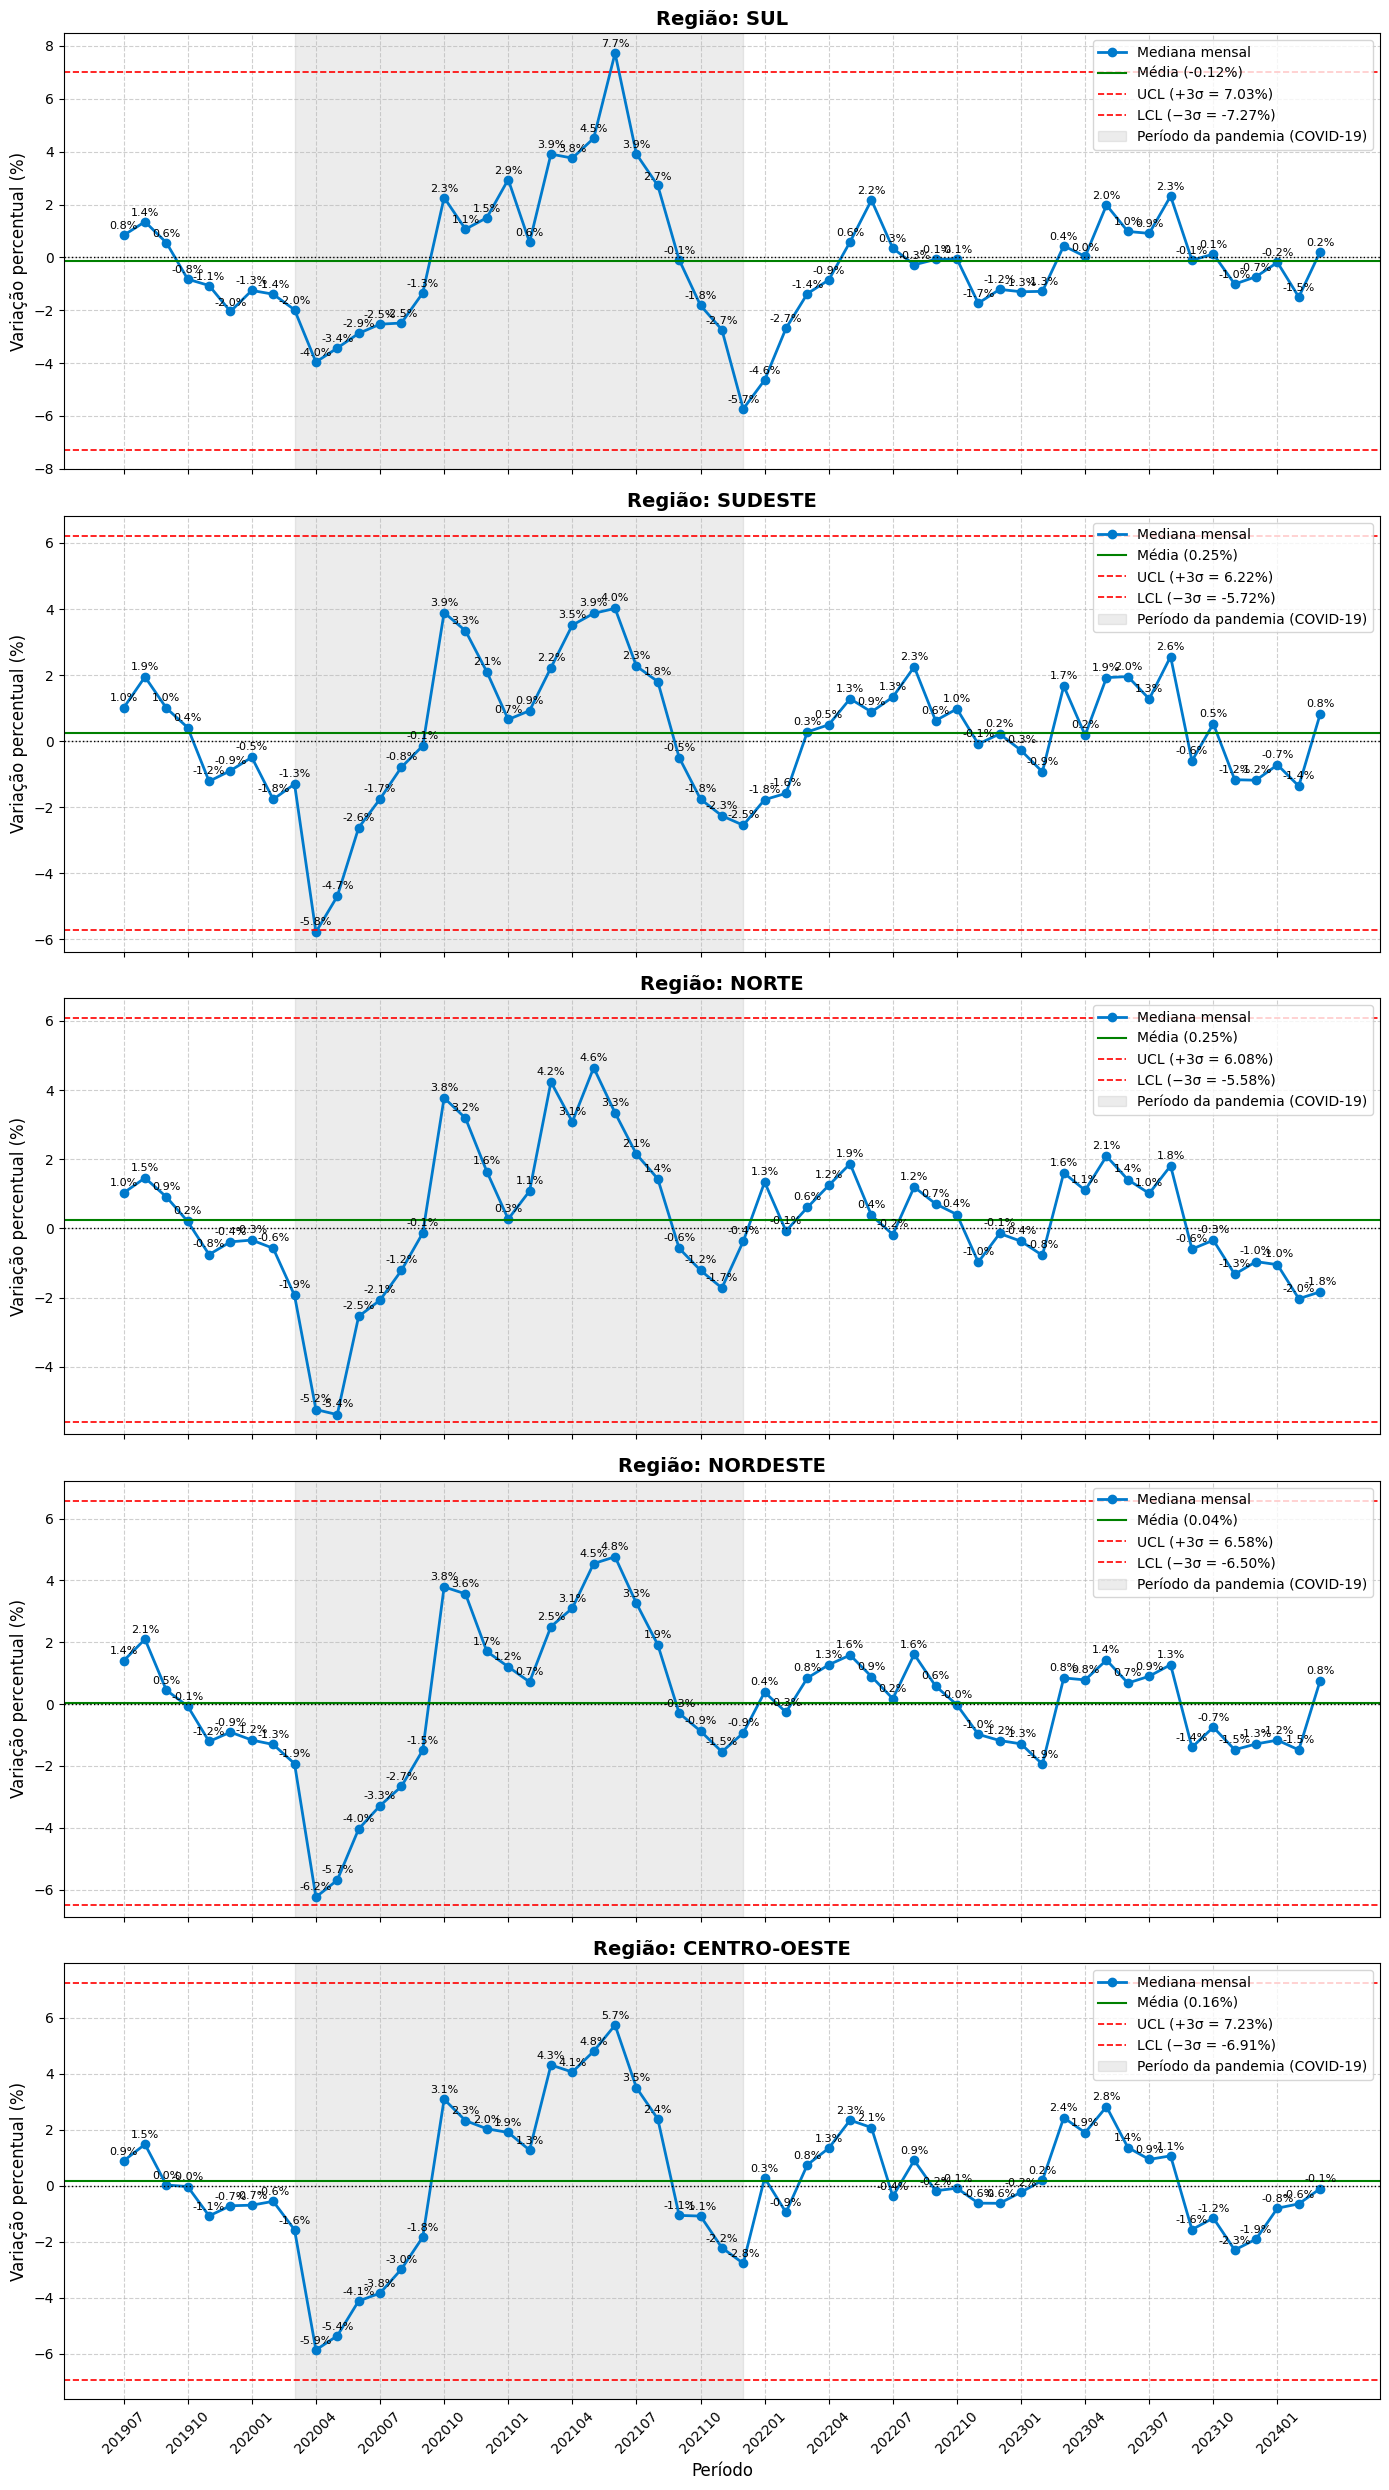

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de regiões únicas
regioes = df['REGIAO'].unique()

# Configuração geral dos gráficos
fig, axes = plt.subplots(len(regioes), 1, figsize=(14, 5*len(regioes)), sharex=True)

if len(regioes) == 1:
    axes = [axes]  # garante iterabilidade caso seja apenas uma região

for ax, regiao in zip(axes, regioes):
    # Subconjunto da região
    df_regiao = df[df['REGIAO'] == regiao]

    # --- Cálculo das medianas percentuais ---
    medianas = (df_regiao.groupby("periodo_t1")["MI"].median() - 1) * 100

    # Média e limites de controle (3σ)
    media = medianas.mean()
    desvio = medianas.std()
    ucl = media + 3 * desvio
    lcl = media - 3 * desvio

    # Plotagem
    ax.plot(medianas.index, medianas.values, marker='o', color='#007acc', linewidth=2, label='Mediana mensal')

    # Rótulos nos pontos
    for x, y in zip(medianas.index, medianas.values):
        ax.text(x, y + 0.15, f"{y:.1f}%", ha='center', va='bottom', fontsize=8, color='black')

    # Linhas de controle
    ax.axhline(media, color='green', linestyle='-', linewidth=1.5, label=f'Média ({media:.2f}%)')
    ax.axhline(ucl, color='red', linestyle='--', linewidth=1.2, label=f'UCL (+3σ = {ucl:.2f}%)')
    ax.axhline(lcl, color='red', linestyle='--', linewidth=1.2, label=f'LCL (−3σ = {lcl:.2f}%)')
    ax.axhline(0, color='black', linestyle=':', linewidth=1)

    # Sombreado pandemia
    pandemia_inicio = "202003"
    pandemia_fim = "202112"
    if pandemia_inicio in medianas.index and pandemia_fim in medianas.index:
        idx_inicio = medianas.index.get_loc(pandemia_inicio)
        idx_fim = medianas.index.get_loc(pandemia_fim)
        ax.axvspan(idx_inicio, idx_fim, color='gray', alpha=0.15, label='Período da pandemia (COVID-19)')

    ax.set_title(f"Região: {regiao}", fontsize=14, weight='bold')
    ax.set_ylabel("Variação percentual (%)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', frameon=True, facecolor='white')

# Configuração do eixo x para todos os gráficos
step = 3
xticks = np.arange(0, len(medianas.index), step)
xticklabels = [medianas.index[i] for i in xticks]
plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Período", fontsize=12)

plt.tight_layout()
plt.show()

# Cálculo dos índices acumulados

In [19]:
# Ordenar por hospital e período
df = df.sort_values(['CNES', 'periodo_t'])

for col in ['MI', 'catch_up', 'frontier_shift']:
    df[col] = df[col].fillna(1)

# Produto acumulado por CNES
df['MI_acumulado'] = df.groupby('CNES')['MI'].cumprod()
df['eff_acumulado'] = df.groupby('CNES')['catch_up'].cumprod()
df['front_acumulado'] = df.groupby('CNES')['frontier_shift'].cumprod()

df = df.drop_duplicates(subset=["CNES"], keep="last")

df.sort_values("MI_acumulado")

,MI,catch_up,frontier_shift,CNES,cluster,periodo_t,periodo_t1,REGIAO,MI_acumulado,eff_acumulado,front_acumulado
73732,1.000000,0.928518,1.076985,4055470,3,202402,202403,SUL,0.003762,0.005646,0.666400
54968,0.931024,0.920783,1.011123,0302961,2,202306,202307,SUDESTE,0.026594,0.091109,0.291896
102330,1.142938,1.115668,1.024443,2664364,5,202312,202401,NORDESTE,0.056943,0.030995,1.837171
56298,0.974244,1.012378,0.962332,0136581,2,202402,202403,NORDESTE,0.061869,0.479776,0.128955
56095,0.766312,0.760599,1.007511,4022068,2,202312,202401,NORDESTE,0.063922,0.089271,0.716046
...,...,...,...,...,...,...,...,...,...,...,...
21812,1.048697,0.988438,1.060964,2667754,0,202402,202403,NORTE,42.703200,30.669687,1.392359
78996,1.206141,1.209854,0.996931,9928510,4,202311,202312,NORDESTE,48.798377,33.875637,1.440515
76541,1.578491,1.000000,1.578491,2465043,4,202111,202112,NORDESTE,50.470694,19.042412,2.650436
78874,0.985607,0.981756,1.003922,2744414,4,202310,202311,NORTE,51.943221,19.802947,2.623005


# Verificar características dos índices

In [21]:
import numpy as np

cols = ['MI','catch_up','frontier_shift']
diag = {}
for c in cols:
    ser = df[c]
    diag[c] = {
        'n_total': len(ser),
        'n_nan': ser.isna().sum(),
        'n_zero': (ser == 0).sum(),
        'n_le0': (ser <= 0).sum(),
        'min': ser.min(skipna=True),
        'max': ser.max(skipna=True)
    }
import pprint
pprint.pprint(diag)

{'MI': {'max': 4.981387596682545,
        'min': 0.3123313223615483,
        'n_le0': 0,
        'n_nan': 0,
        'n_total': 2722,
        'n_zero': 0},
 'catch_up': {'max': 5.07457597822476,
              'min': 0.24325365980072447,
              'n_le0': 0,
              'n_nan': 0,
              'n_total': 2722,
              'n_zero': 0},
 'frontier_shift': {'max': 3.6563461260157792,
                    'min': 0.7783303395246506,
                    'n_le0': 0,
                    'n_nan': 0,
                    'n_total': 2722,
                    'n_zero': 0}}


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2722 entries, 111267 to 21604
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MI               2722 non-null   float64
 1   catch_up         2722 non-null   float64
 2   frontier_shift   2722 non-null   float64
 3   CNES             2722 non-null   object 
 4   cluster          2722 non-null   int32  
 5   periodo_t        2722 non-null   object 
 6   periodo_t1       2722 non-null   object 
 7   REGIAO           2722 non-null   object 
 8   MI_acumulado     2722 non-null   float64
 9   eff_acumulado    2722 non-null   float64
 10  front_acumulado  2722 non-null   float64
dtypes: float64(6), int32(1), object(4)
memory usage: 244.6+ KB


# Resultado mediano geral dos índices acumulados

In [23]:
import pandas as pd
import numpy as np

# Medianas acumuladas
medianas = df[["MI_acumulado", "eff_acumulado", "front_acumulado"]].median()

# Converter para variação percentual e formatar
variacao_percentual = medianas.map(lambda x: f"{(x - 1) * 100:.2f}%")

print(variacao_percentual)

MI_acumulado         5.36%
eff_acumulado      -10.95%
front_acumulado     17.69%
dtype: object


# Gráfico do Brasil

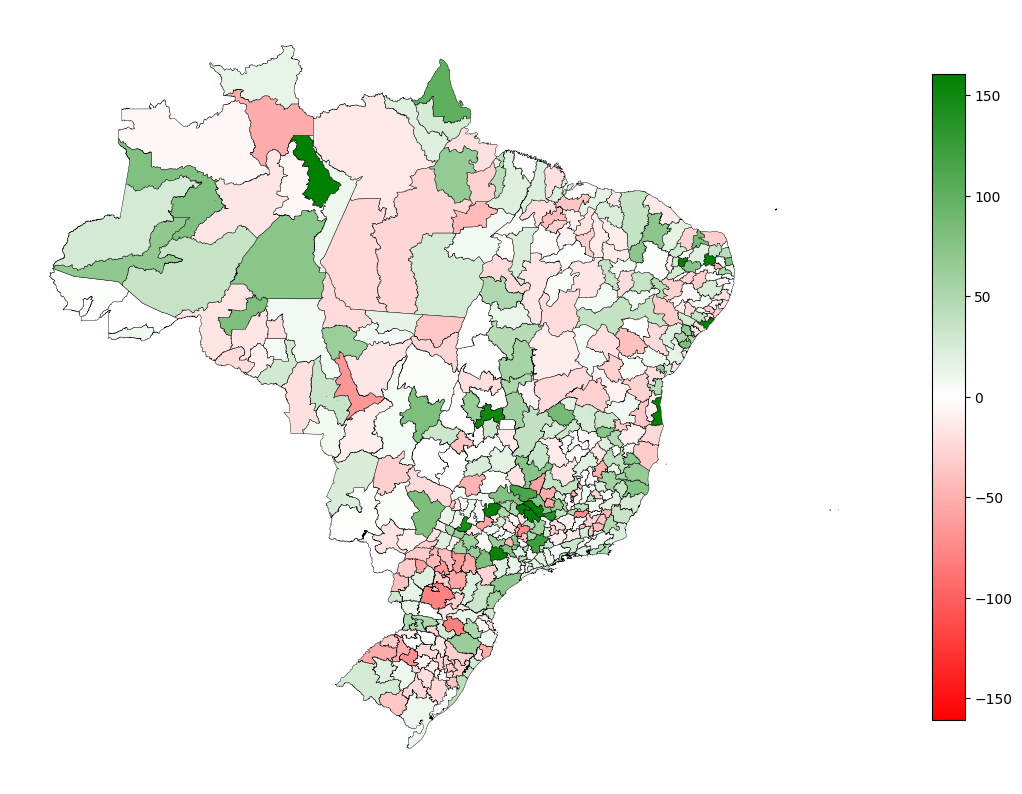

In [24]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import LinearSegmentedColormap

# Carregar dados
reg = pd.read_pickle("../Bases/regioes_final.pkl")
gdf = gpd.read_file("../Bases/BR_Municipios_2024_final.shp")

# Garantir que os códigos são inteiros
gdf["Codigo R_1"] = gdf["Codigo R_1"].astype(int)
reg["Codigo Regiao de Saude"] = reg["Codigo Regiao de Saude"].astype(int)

# Calcular mediana de MI por região
df_regiao = df.groupby('CNES')['MI_acumulado'].median().reset_index()
df_regiao = reg.merge(df_regiao, on='CNES', how='left')
df_regiao = df_regiao.groupby('Codigo Regiao de Saude')['MI_acumulado'].median().reset_index()
df_regiao.rename(columns={'MI_acumulado': 'Produtividade'}, inplace=True)

# Merge com GeoDataFrame
gdf = gdf.merge(df_regiao, left_on="Codigo R_1", right_on="Codigo Regiao de Saude", how="left")

# Transformar produtividade em variação percentual
gdf["Produtividade_percent"] = (gdf["Produtividade"] - 1) * 100

# Interpolação apenas se necessário
gdf["Produtividade_percent"] = gdf["Produtividade_percent"].interpolate(method="linear")

# Colormap personalizado: vermelho -> branco -> verde
colors = ["red", "white", "green"]
cmap = LinearSegmentedColormap.from_list("red_white_green", colors)

lower = gdf["Produtividade_percent"].quantile(0.02)
upper = gdf["Produtividade_percent"].quantile(0.98)
abs_max = max(abs(lower), abs(upper))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)


# Plotar
fig, ax = plt.subplots(1, 1, figsize=(14, 14))
gdf.plot(
    ax=ax,
    column='Produtividade_percent',
    cmap=cmap,
    edgecolor='black',
    linewidth=0.3,
    legend=True,
    norm=norm,
    legend_kwds={'shrink': 0.6}
)

ax.axis('off')

plt.savefig("../Figuras/evolucao_produtividade_percentual.png", dpi=300, bbox_inches='tight')
plt.show()

# Verificação de quantas regiões de saúde melhoraram ou pioraram

In [502]:
import numpy as np

df_regiao["marcador"] = np.select(
    [
        df_regiao["Produtividade"] > 1,
        df_regiao["Produtividade"] == 0
    ],
    [
        2,  # condição 1: produtividade > 1
        1   # condição 2: produtividade == 0
    ],
    default=0  # todos os outros casos
)
df_regiao.marcador.value_counts()

marcador
2    211
0    160
Name: count, dtype: int64

# Número de regiões de saúde com produtividade acumulada inferior a 5%

In [504]:
df_regiao["val"] = df_regiao["Produtividade"] - 1
df_regiao["val"] = np.abs(df_regiao["val"])

count_baixo = (df_regiao["val"] < 0.05).sum()
total = len(df_regiao)
proporcao = count_baixo / total * 100

print(f"Número de registros com val < 0.05: {count_baixo}")
print(f"Proporção: {proporcao:.2f}%")


Número de registros com val < 0.05: 48
Proporção: 12.94%


In [505]:
import numpy as np

# Calcula a diferença em relação a 1
df_regiao["val"] = df_regiao["Produtividade"] - 1

# Filtro para variações de até ±0.05
mask = np.abs(df_regiao["val"]) < 0.05

# Contagens separadas
positivas = ((df_regiao["val"] > 0) & mask).sum()
negativas = ((df_regiao["val"] < 0) & mask).sum()

print(f"Variações positivas (< 5%): {positivas}")
print(f"Variações negativas (< 5%): {negativas}")


Variações positivas (< 5%): 27
Variações negativas (< 5%): 21


# Regioes que mais pioraram

In [25]:
df_regiao = df_regiao.merge(reg[["Codigo Regiao de Saude", "Regiao de Saude", "UF"]], on="Codigo Regiao de Saude", how="left")
df_regiao["Regiao de Saude"] = df_regiao["Regiao de Saude"].str.lower()
df_regiao

,Codigo Regiao de Saude,Produtividade,Regiao de Saude,UF
0,11001,1.815764,vale do jamari,RO
1,11001,1.815764,vale do jamari,RO
2,11001,1.815764,vale do jamari,RO
3,11001,1.815764,vale do jamari,RO
4,11001,1.815764,vale do jamari,RO
...,...,...,...,...
134360,53001,0.987630,distrito federal,DF
134361,53001,0.987630,distrito federal,DF
134362,53001,0.987630,distrito federal,DF
134363,53001,0.987630,distrito federal,DF


In [356]:
df_regiao.Produtividade.sort_values()

115091    0.201532
115068    0.201532
115067    0.201532
115066    0.201532
115065    0.201532
            ...   
83691     4.443098
83692     4.443098
83693     4.443098
83723     4.443098
83753     4.443098
Name: Produtividade, Length: 134365, dtype: float64

In [26]:
# Calcular número de hospitais por região de saúde
reg1 = reg.copy()
reg1 = reg1.drop_duplicates(subset=["CNES"])
reg1 = reg1.groupby("Regiao de Saude")["CNES"].nunique().reset_index()
reg1["Regiao de Saude"] = reg1["Regiao de Saude"].astype(str).str.lower()
reg1 = reg1.rename(columns={"CNES": "n_hosp"})
df_regiao = df_regiao.merge(reg1, on="Regiao de Saude", how="left")

In [27]:
df_regiao = df_regiao.drop_duplicates(subset=["Codigo Regiao de Saude"])

,Codigo Regiao de Saude,Produtividade,Regiao de Saude,UF,n_hosp
0,11001,1.815764,vale do jamari,RO,11
531,11002,1.073486,cafe,RO,7
814,11003,0.830723,central,RO,46
1232,11004,0.831626,madeira-mamore,RO,11
1755,11005,0.909325,zona da mata,RO,6
...,...,...,...,...,...
131361,52015,1.009187,sudoeste i,GO,17
132284,52016,0.995820,sudoeste ii,GO,8
132733,52017,1.250042,sul,GO,19
133227,52018,2.507656,sao patricio ii,GO,5


In [28]:
df_new = df1.groupby("Codigo Regiao de Saude")[["Var_Ef_percent", "Eficiência"]].median().reset_index()
df_regiao = df_regiao.merge(df_new, on="Codigo Regiao de Saude", how="left")

,Codigo Regiao de Saude,Produtividade,Regiao de Saude,UF,n_hosp,Var_Ef_percent,Eficiência
0,11001,1.815764,vale do jamari,RO,11,-1.962046,0.768291
1,11002,1.073486,cafe,RO,7,3.505873,0.712822
2,11003,0.830723,central,RO,46,1.199035,0.681890
3,11004,0.831626,madeira-mamore,RO,11,0.000000,0.700237
4,11005,0.909325,zona da mata,RO,6,-5.678885,0.619510
...,...,...,...,...,...,...,...
366,52015,1.009187,sudoeste i,GO,17,-2.367679,0.760291
367,52016,0.995820,sudoeste ii,GO,8,-10.482726,0.720589
368,52017,1.250042,sul,GO,19,0.455619,0.723911
369,52018,2.507656,sao patricio ii,GO,5,0.000001,0.836873


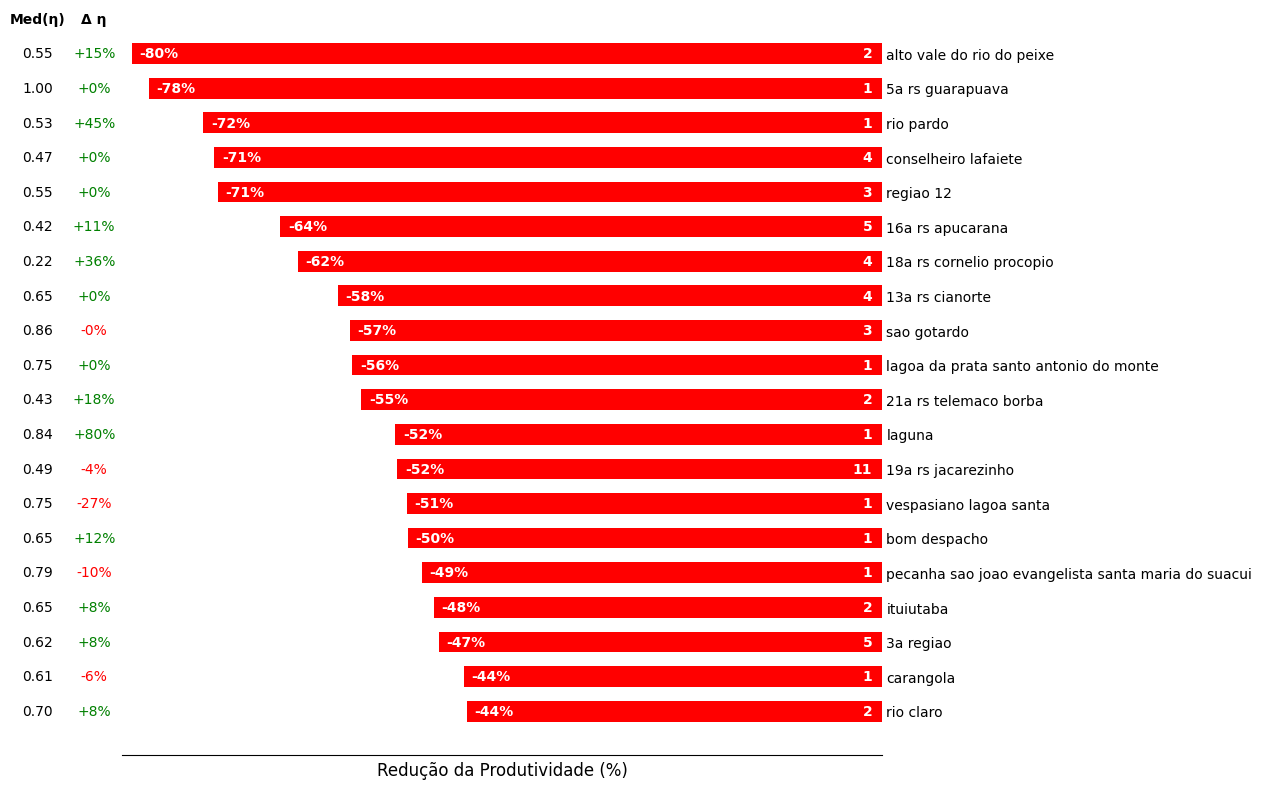

In [432]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcdefaults()
fig, ax1 = plt.subplots(figsize=(13, 8))

# Dados base
df_regiao["Regiao de Saude"] = df_regiao["Regiao de Saude"].str.lower()

# 20 piores regiões pela mediana de produtividade
sub = df_regiao.groupby("Regiao de Saude")["Produtividade"].median().sort_values().head(20)
sub_percent = (sub - 1) * 100
regioes = sub_percent.index

# Dados complementares
n_hosp = df_regiao.groupby("Regiao de Saude")["n_hosp"].first().reindex(regioes)
eficiencia = df_regiao.groupby("Regiao de Saude")["Eficiência"].median().reindex(regioes)
var_ef = df_regiao.groupby("Regiao de Saude")["Var_Ef_percent"].median().reindex(regioes)

# Barras principais
bars = ax1.barh(regioes, sub_percent.values, color="red", height=0.6, zorder=2)

ax1.set_xlim(sub_percent.min() - 1, 0)
ax1.set_xlabel("Redução da Produtividade (%)", fontsize=12)
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.tick_params(axis='y', length=0)
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")
ax1.invert_yaxis()
ax1.set_xticks([])

# Ajuste de espaço para os textos
x_left = sub_percent.min() - 10  # desloca para a esquerda
col_gap = 4                      # distância entre as colunas

y_header = bars[0].get_y() - 0.5

# Cabeçalhos
ax1.text(x_left + col_gap*0, y_header, "Med(η)", 
         fontsize=10, fontweight='bold', ha='center', va='bottom')
ax1.text(x_left + col_gap*1+2, y_header, r"Δ η", 
         fontsize=10, fontweight='bold', ha='center', va='bottom')

# Inserir textos alinhados às barras
for i, (bar, med, var) in enumerate(zip(bars, eficiencia, var_ef)):
    y = bar.get_y() + bar.get_height()/2
    color_var = 'green' if var >= 0 else 'red'

    # Mediana da eficiência
    ax1.text(x_left + col_gap*0, y, f"{med:.2f}",
             ha='center', va='center', fontsize=10, color='black')

    # Variação da eficiência
    ax1.text(x_left + col_gap*1+2, y, f"{var:+.0f}%",
             ha='center', va='center', fontsize=10, color=color_var)

# Textos nas barras (produtividade e n_hosp)
for bar, nh in zip(bars, n_hosp):
    ax1.text(bar.get_width() + 5,
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}%",
             va='center', ha='right', fontsize=10, color='white', fontweight="bold")
    ax1.text(-1,
             bar.get_y() + bar.get_height()/2,
             f"{nh}",
             va='center', ha='right', fontsize=10, color='white', fontweight="bold")

plt.tight_layout()
plt.savefig("../Figuras/menos_prod.png", dpi=300)
plt.show()

In [198]:
# Filtrar apenas as regiões do gráfico
regioes_selecionadas = sub.index
df_sub = df_regiao[df_regiao["Regiao de Saude"].isin(regioes_selecionadas)].drop_duplicates(subset=["Codigo Regiao de Saude"])

# Contar quantas vezes cada UF aparece nessas regiões
ufs_contagem = df_sub["UF"].value_counts()

# Converter para percentual
ufs_percentual = (ufs_contagem / ufs_contagem.sum()) * 100

# Mostrar resultados
print("Percentual de UFs nas regiões com maior crescimento de produtividade:")
for uf, perc in ufs_percentual.sort_values(ascending=False).items():
    print(f"{uf}: {perc:.0f}%")

Percentual de UFs nas regiões com maior crescimento de produtividade:
MG: 40%
PR: 30%
SP: 10%
SC: 10%
PB: 5%
RS: 5%


# Evolução da eficiência das regiões de saúde com maior queda de produtividade

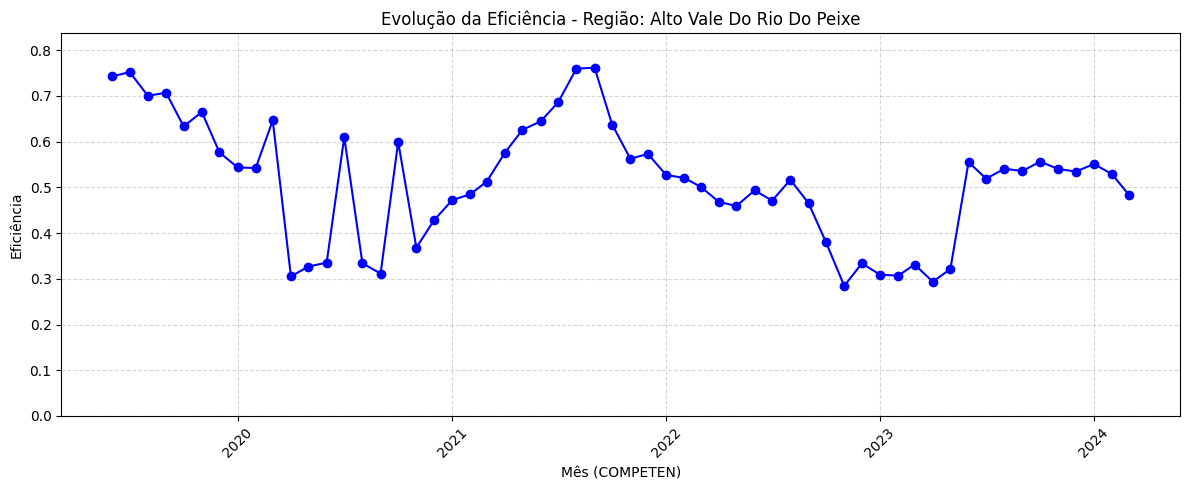

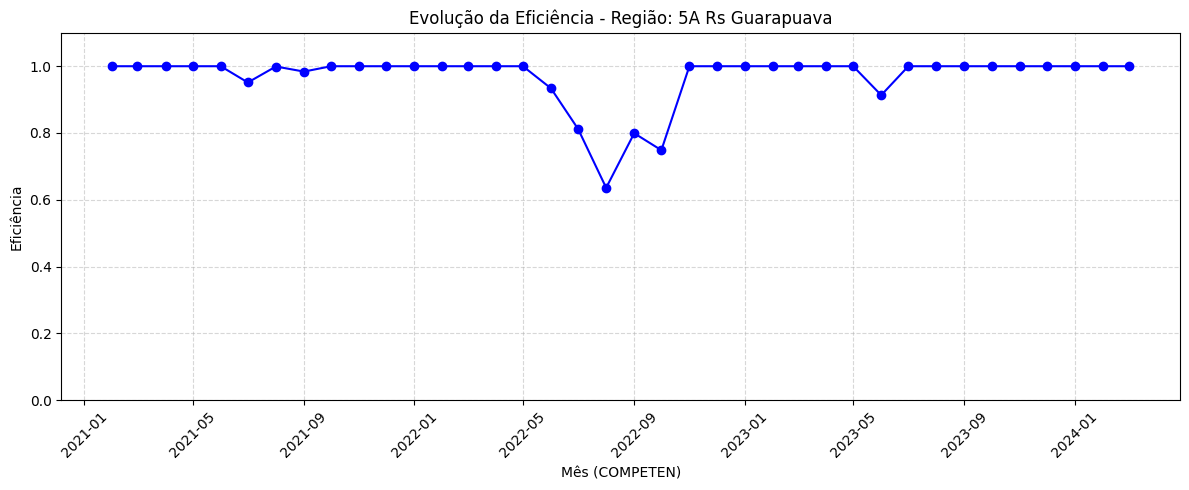

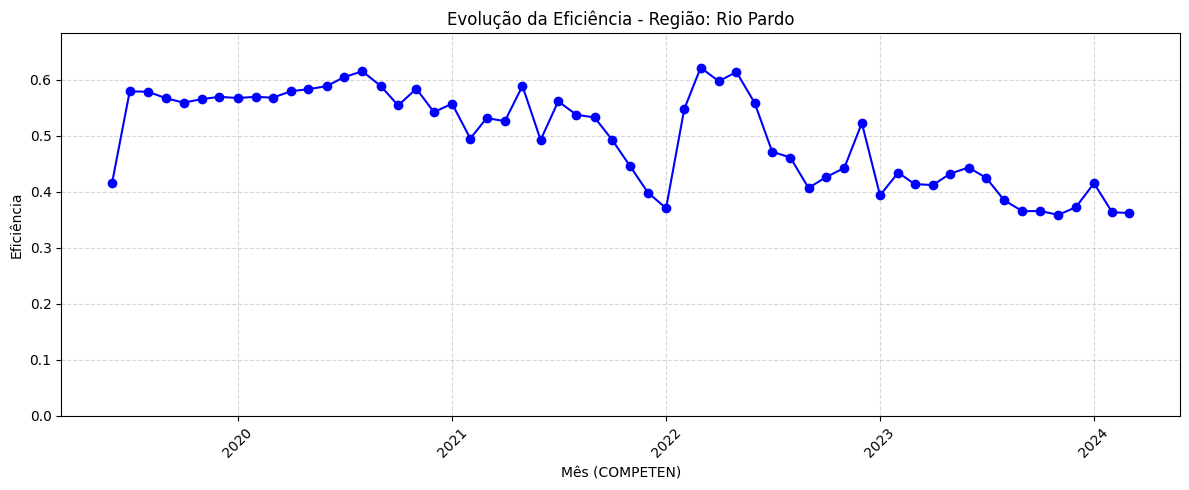

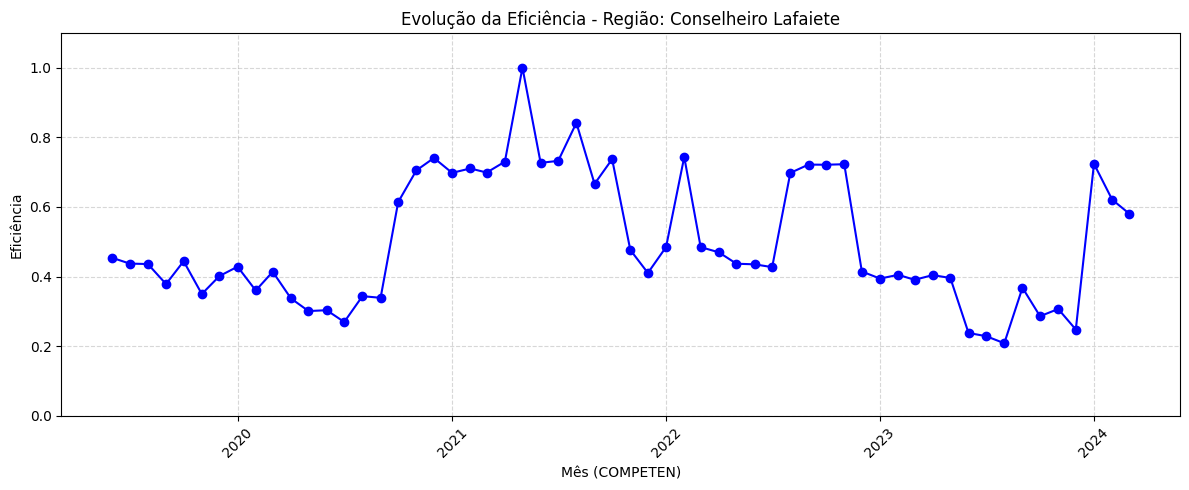

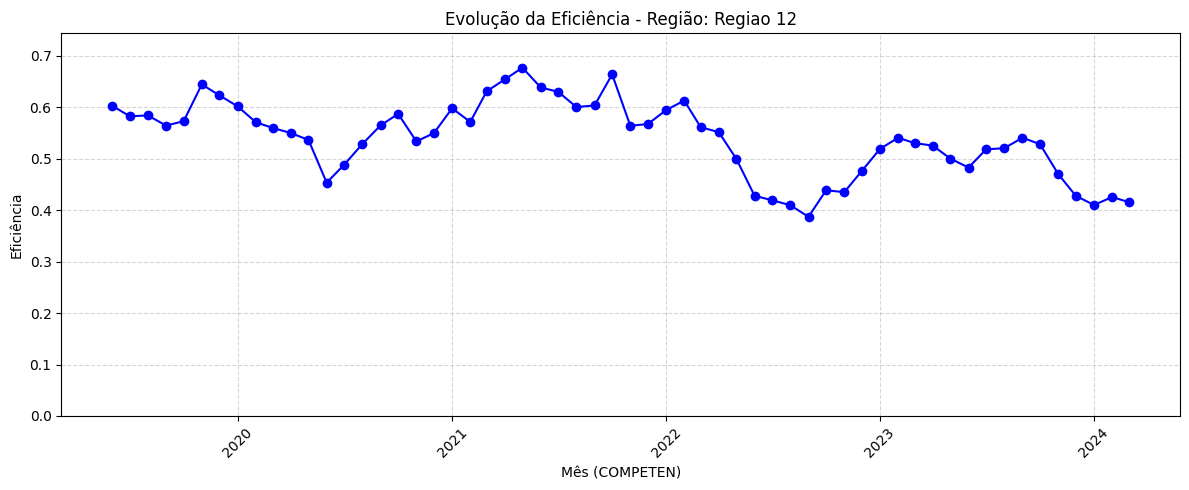

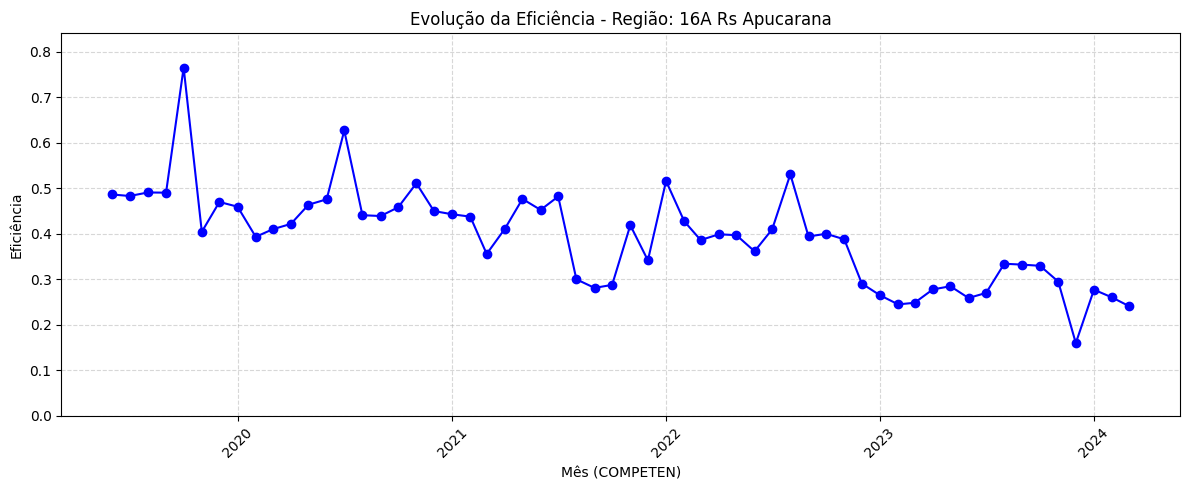

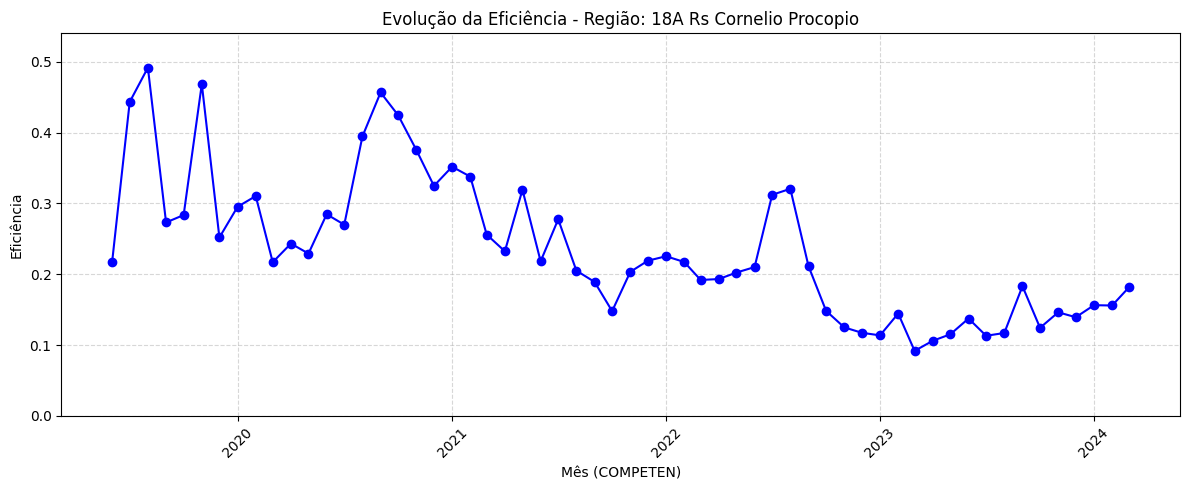

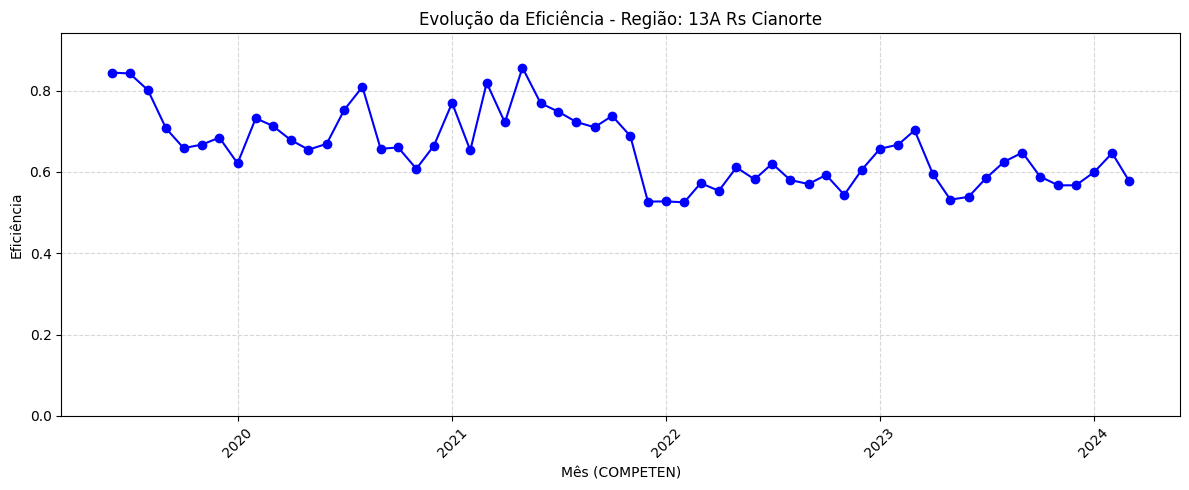

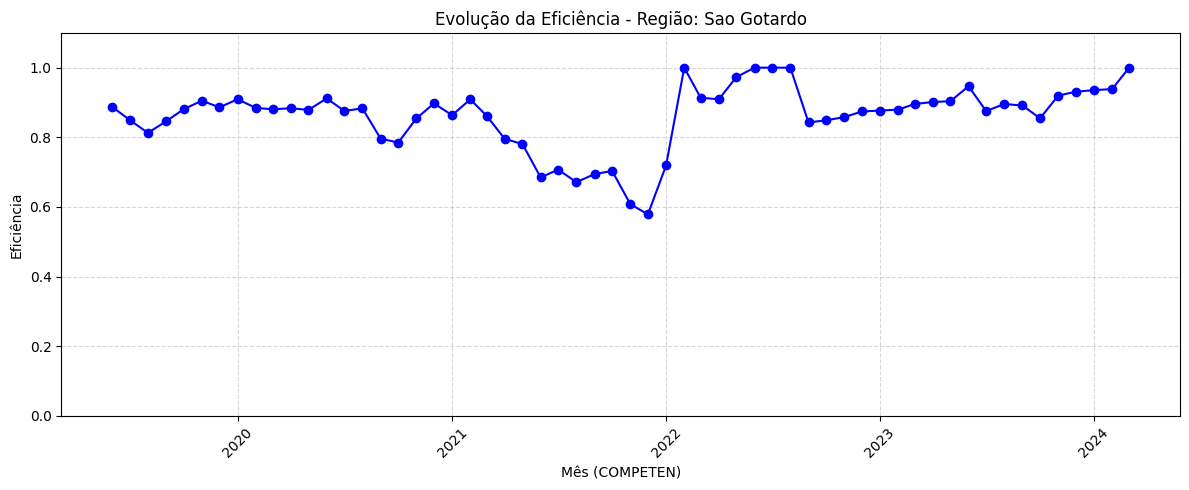

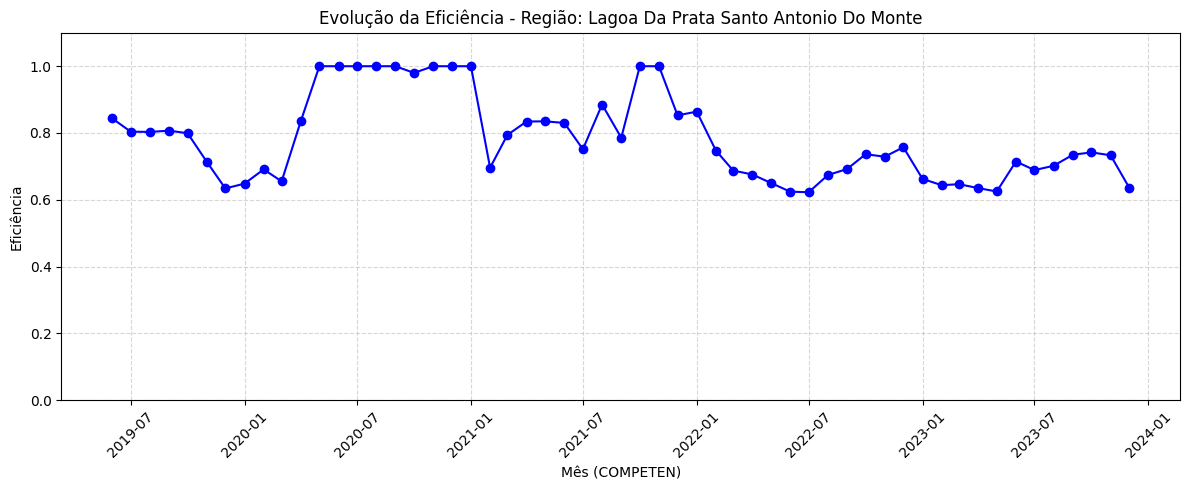

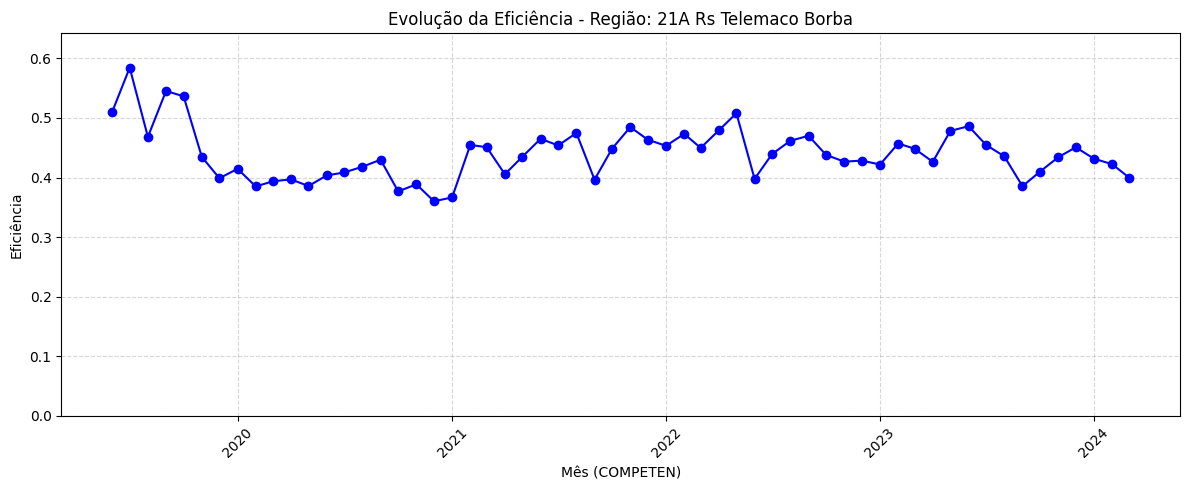

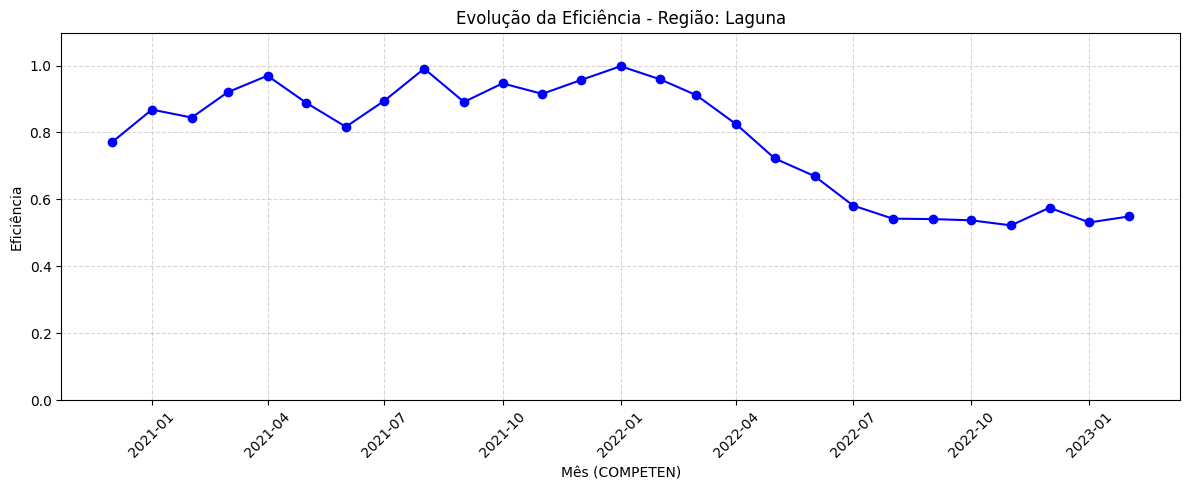

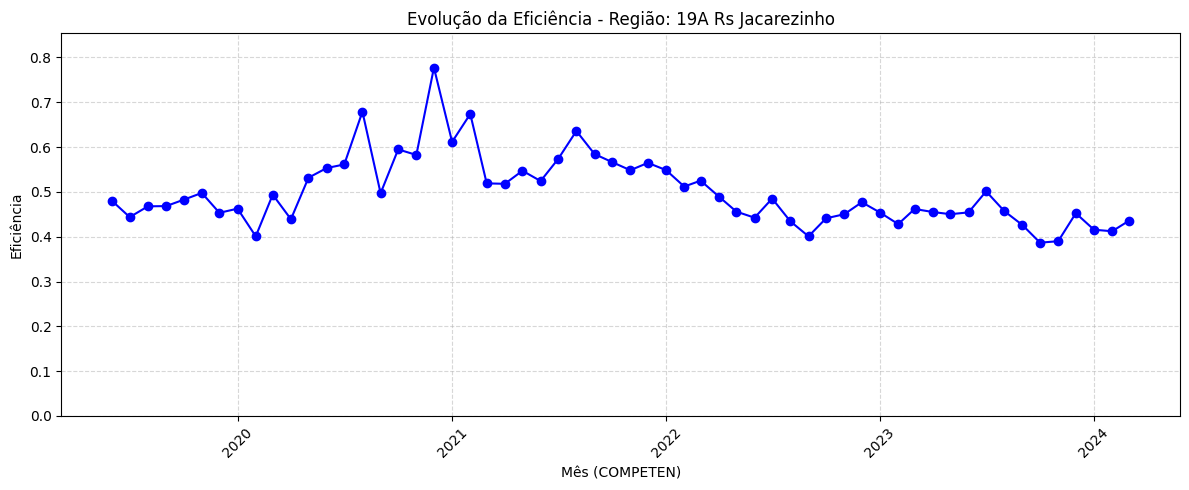

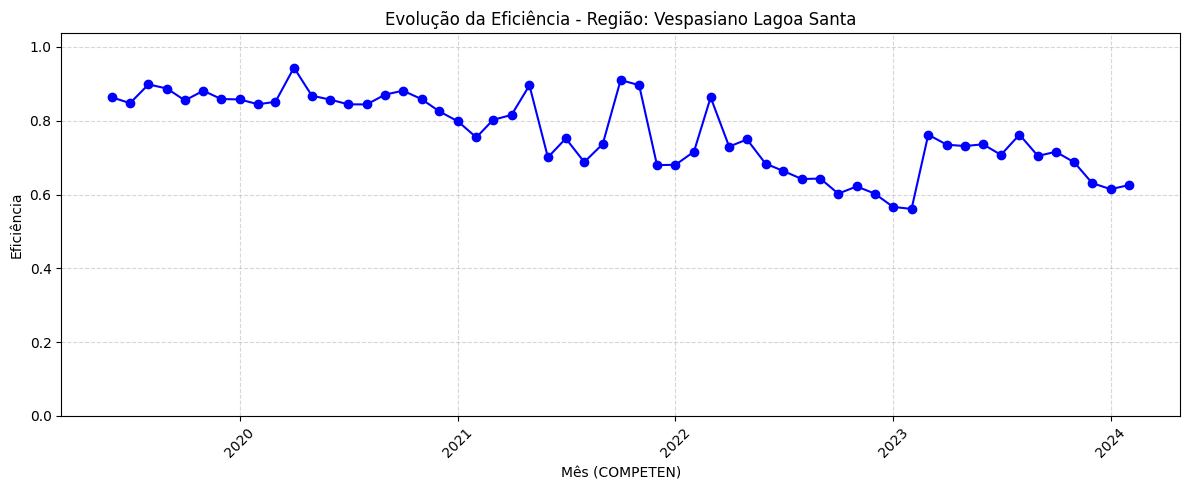

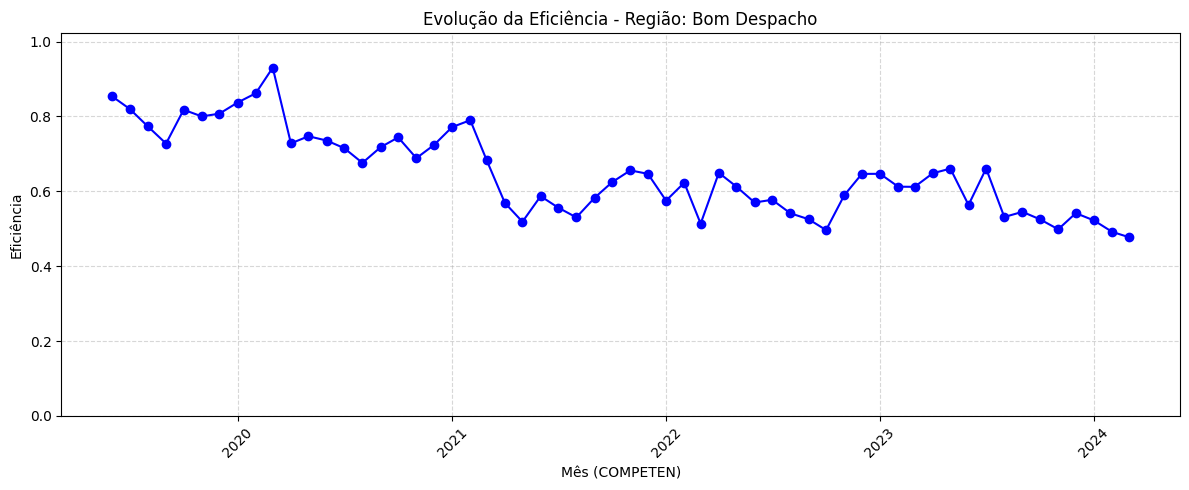

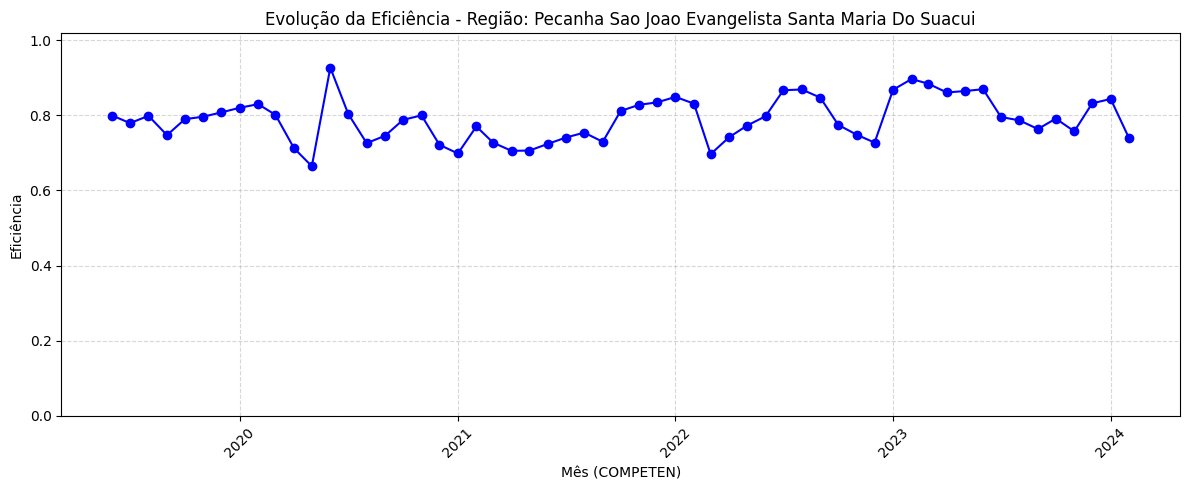

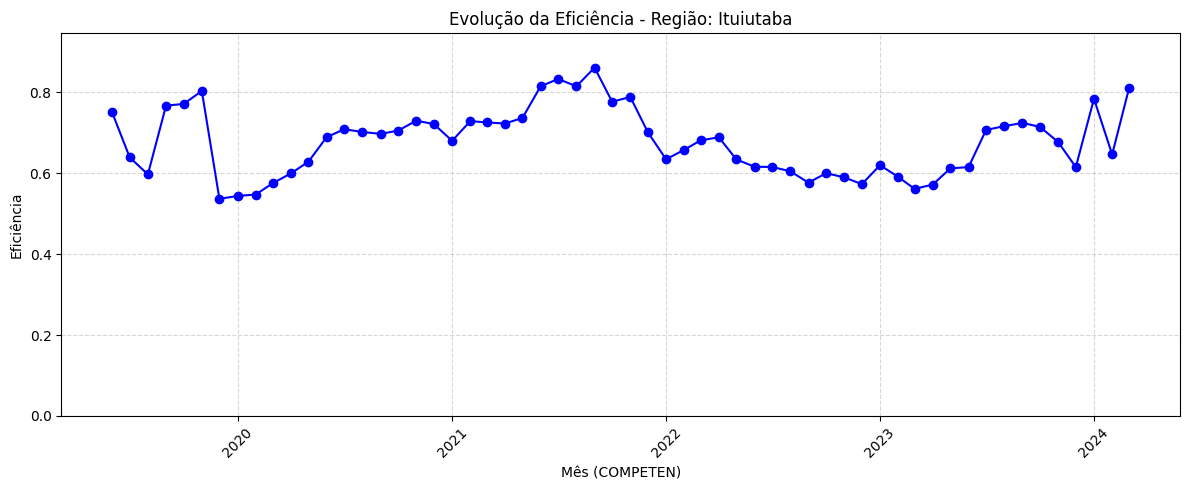

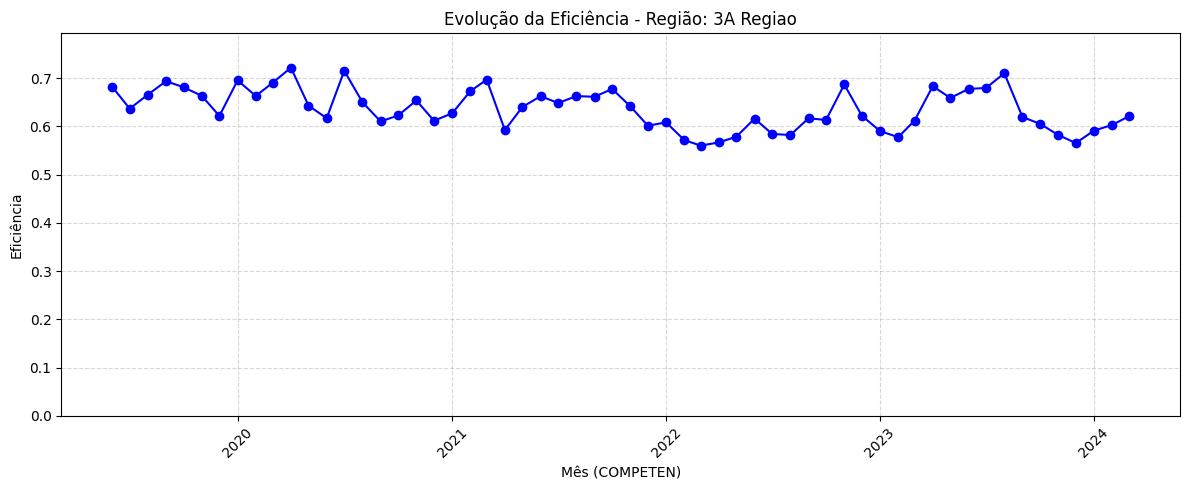

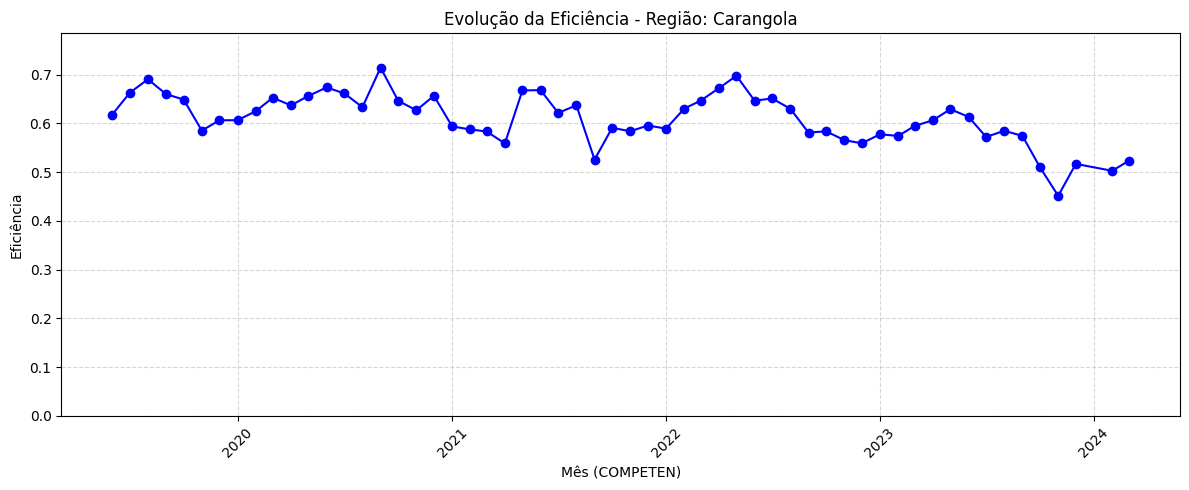

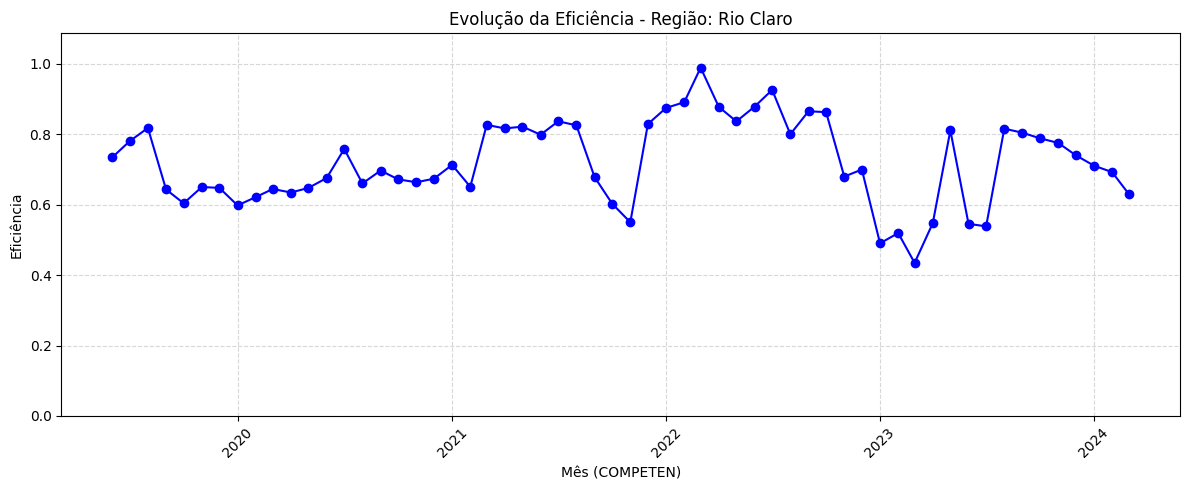

In [206]:
import matplotlib.pyplot as plt
import pandas as pd

sup = pd.read_pickle("../Bases/regioes_final.pkl")
sup["Regiao de Saude"] = sup["Regiao de Saude"].str.lower()

# Filtrar apenas as regiões selecionadas
df_sel = sup[sup["Regiao de Saude"].isin(regioes_selecionadas)]

# Garantir que COMPETEN está ordenado
df_sel = df_sel.sort_values(["Regiao de Saude", "COMPETEN"])

# Agrupar por região e mês, calculando a mediana da Eficiência
df_plot = df_sel.groupby(["COMPETEN", "Regiao de Saude"])["Eficiência"].median().reset_index()

# Plot individual por região
for regiao in regioes_selecionadas:
    df_temp = df_plot[df_plot["Regiao de Saude"] == regiao]
    
    plt.figure(figsize=(12, 5))
    plt.plot(df_temp["COMPETEN"], df_temp["Eficiência"], marker='o', color='blue')
    plt.xlabel("Mês (COMPETEN)")
    plt.ylabel("Eficiência")
    plt.title(f"Evolução da Eficiência - Região: {regiao.title()}")
    plt.xticks(rotation=45)
    plt.ylim(0, df_temp["Eficiência"].max()*1.1)  # ajustar limite superior
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# Melhores regioes

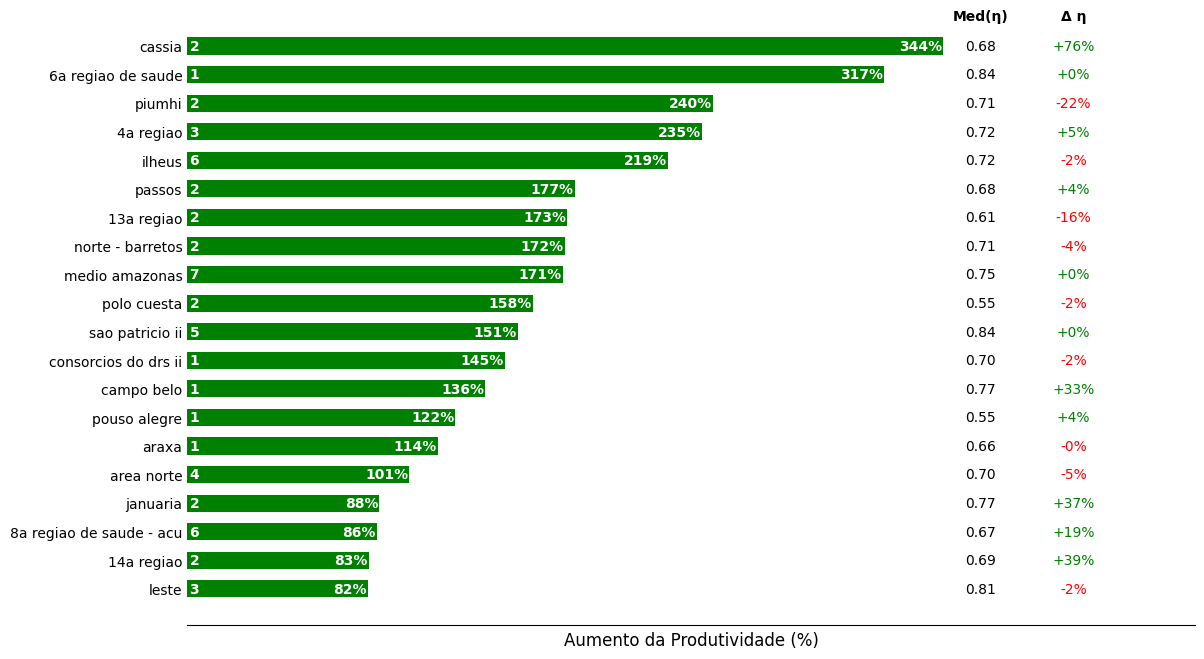

In [433]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcdefaults()
fig, ax1 = plt.subplots(figsize=(13, 8))

# Dados base
df_regiao["Regiao de Saude"] = df_regiao["Regiao de Saude"].str.lower()

# 20 melhores regiões pela mediana de produtividade
sub = df_regiao.groupby("Regiao de Saude")["Produtividade"].median().sort_values(ascending=False).head(20)
sub_percent = (sub - 1) * 100
regioes = sub_percent.index

# Dados complementares
n_hosp = df_regiao.groupby("Regiao de Saude")["n_hosp"].first().reindex(regioes)
eficiencia = df_regiao.groupby("Regiao de Saude")["Eficiência"].median().reindex(regioes)
var_ef = df_regiao.groupby("Regiao de Saude")["Var_Ef_percent"].median().reindex(regioes)

# Definir limites com 25% do espaço para a tabela
max_bar = sub_percent.max()
xlim_total = max_bar / 0.75   # 75% gráfico, 25% tabela
ax1.set_xlim(0, xlim_total)

# Barras principais
bars = ax1.barh(regioes, sub_percent.values, color="green", height=0.6, zorder=2)

ax1.set_xlabel("Aumento da Produtividade (%)", fontsize=12)
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.tick_params(axis='y', length=0)
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
ax1.invert_yaxis()
ax1.set_xticks([])

# Posição inicial da tabela (75% da largura)
table_start = max_bar * 1.05
col_gap = (xlim_total - table_start) / 3  # espaçamento proporcional entre colunas

# Cabeçalhos da tabela
y_header = bars[0].get_y() - 0.5
ax1.text(table_start + col_gap*0, y_header, r"Med(η)", 
         fontsize=10, fontweight='bold', ha='center', va='bottom')
ax1.text(table_start + col_gap*1.3, y_header, r"Δ η", 
         fontsize=10, fontweight='bold', ha='center', va='bottom')

# Inserir textos alinhados às barras
for i, (bar, med, var) in enumerate(zip(bars, eficiencia, var_ef)):
    y = bar.get_y() + bar.get_height()/2
    color_var = 'green' if var >= 0 else 'red'

    # Mediana da eficiência
    ax1.text(table_start + col_gap*0, y, f"{med:.2f}",
             ha='center', va='center', fontsize=10, color='black')

    # Variação da eficiência
    ax1.text(table_start + col_gap*1.3, y, f"{var:+.0f}%",
             ha='center', va='center', fontsize=10, color=color_var)

# Textos nas barras (produtividade e n_hosp)
for bar, nh in zip(bars, n_hosp):
    # Valor da produtividade
    ax1.text(bar.get_width() - 0.5,
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}%",
             va='center', ha='right', fontsize=10, color='white', fontweight="bold")

    # Número de hospitais no início da barra
    ax1.text(1,
             bar.get_y() + bar.get_height()/2,
             f"{nh}",
             va='center', ha='left', fontsize=10, color='white', fontweight="bold")

plt.savefig("../Figuras/melhores_prod_tabela_direita.png", dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Filtrar apenas as regiões do gráfico
regioes_selecionadas = sub.index
df_sub = df_regiao[df_regiao["Regiao de Saude"].isin(regioes_selecionadas)].drop_duplicates(subset=["Codigo Regiao de Saude"])

# Contar quantas vezes cada UF aparece nessas regiões
ufs_contagem = df_sub["UF"].value_counts()

# Converter para percentual
ufs_percentual = (ufs_contagem / ufs_contagem.sum()) * 100

# Mostrar resultados
print("Percentual de UFs nas regiões com maior crescimento de produtividade:")
for uf, perc in ufs_percentual.sort_values(ascending=False).items():
    print(f"{uf}: {perc:.0f}%")

Percentual de UFs nas regiões com maior crescimento de produtividade:
MG: 35%
PB: 15%
SP: 15%
AM: 5%
AP: 5%
RN: 5%
AL: 5%
BA: 5%
MS: 5%
GO: 5%


In [ ]:
original = pd.read_excel("../Bases/regioes_final_completo.xlsx")
original

# Evolução dos inputs e outputs da pior região

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar apenas a pior região
df_alto = original[original["Região de Saúde"].str.lower() == "alto vale do rio do peixe"]

# Colunas de interesse
indicadores = ["CNES_SALAS", "CNES_LEITOS_SUS", "HORAS_MEDICOS", "HORAS_ENFERMAGEM", "SIA_SIH_VALOR"]

# Agrupar por período e calcular mediana
df_median = df_alto.groupby("COMPETEN")[indicadores].sum().reset_index()

# Calcular variação percentual entre último e primeiro período
var_percent = ((df_median.iloc[-1][indicadores] - df_median.iloc[0][indicadores]) / df_median.iloc[0][indicadores]) * 100
var_percent = var_percent.round(2)  # arredondar para 2 casas decimais

# Exibir a tabela de variação percentual
print("Variação percentual do primeiro para o último período (%):")
print(var_percent)

# Plotar cada indicador separadamente
for col in indicadores:
    plt.figure(figsize=(12, 6))
    plt.plot(
        df_median["COMPETEN"], 
        df_median[col], 
        marker='o', 
        linestyle='-', 
        color='tab:blue' if col != "SIA_SIH_VALOR" else 'tab:green'
    )
    plt.xlabel("Período")
    plt.ylabel(f"Mediana de {col}")
    plt.title(f"Evolução histórica de {col} - Região de Saúde Alto Vale do Rio do Peixe\nVariação: {var_percent[col]:.0f}%")
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Evolução dos inputs e outputs da melhor região

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar apenas a melhor região
df_alto = original[original["Região de Saúde"].str.lower() == "cassia"]

# Colunas de interesse
indicadores = ["CNES_SALAS", "CNES_LEITOS_SUS", "HORAS_MEDICOS", "HORAS_ENFERMAGEM", "SIA_SIH_VALOR"]

# Agrupar por período e calcular mediana
df_median = df_alto.groupby("COMPETEN")[indicadores].median().reset_index()

# Calcular variação percentual entre último e primeiro período
var_percent = ((df_median.iloc[-1][indicadores] - df_median.iloc[0][indicadores]) / df_median.iloc[0][indicadores]) * 100
var_percent = var_percent.round(2)  # arredondar para 2 casas decimais

# Exibir a tabela de variação percentual
print("Variação percentual do primeiro para o último período (%):")
print(var_percent)

# Plotar cada indicador separadamente
for col in indicadores:
    plt.figure(figsize=(12, 6))
    plt.plot(
        df_median["COMPETEN"], 
        df_median[col], 
        marker='o', 
        linestyle='-', 
        color='tab:blue' if col != "SIA_SIH_VALOR" else 'tab:green'
    )
    plt.xlabel("Período")
    plt.ylabel(f"Mediana de {col}")
    plt.title(f"Evolução histórica de {col} - Região de Saúde Cassia\nVariação: {var_percent[col]:.0f}%")
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Evolução da produtividade por perfil hospitalar

In [190]:
df1 = df1.drop_duplicates(subset=["CNES"], keep="last")

df1 = df1.merge(df[["CNES", "MI_acumulado", "eff_acumulado", "front_acumulado"]], on="CNES", how="left")

,CNES,CNES_SALAS,CNES_LEITOS_SUS,HORAS_MEDICOS,HORAS_ENFERMAGEM,SIA_SIH_VALOR,COMPETEN,Eficiência,H_enfermagem_por_Leito,Distancia,...,Focos de Calor,Mortes por Acidente de Transporte,Fundamentos do Bem-estar,Necessidades Humanas Básicas,Índice de Progresso Social,Área (km²),Var_Ef_percent,MI_acumulado,eff_acumulado,front_acumulado
0,2321556,14.000000,39.000000,32.000000,496.000000,1.876129e+04,2021-07-01,0.602746,12.717949,0.000000,...,2.050441,27.339211,59.863321,68.887048,56.120165,155.452,11.385418,1.199815,0.383263,3.130529
1,2492342,15.000000,50.000000,859.000000,1510.000000,7.507407e+04,2022-11-01,0.635958,30.200000,0.207448,...,0.428165,18.411081,64.285816,80.329016,61.950488,267.514,-1.062560,1.181105,1.121723,1.052938
2,2504502,34.166667,29.666667,1343.333333,3972.000000,1.042278e+05,2023-11-01,0.643990,133.887640,0.076938,...,3.953257,27.514667,63.691843,79.437802,62.327114,562.703,-3.355341,0.880010,2.925636,0.300793
3,2572265,14.000000,21.000000,83.666667,424.666667,3.511770e+03,2023-03-01,0.396745,20.222222,0.297433,...,4.256225,5.320281,63.891410,77.580534,61.814942,208.470,0.000000,NaN,NaN,NaN
4,2576430,17.000000,30.000000,134.000000,576.000000,5.121565e+03,2020-05-01,0.388753,19.200000,0.175039,...,0.610165,34.169260,63.274472,80.595288,62.550269,715.943,-2.319839,0.924323,0.869778,1.062712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2727,9917322,48.000000,360.000000,2608.666667,32697.333333,3.267451e+06,2023-11-01,1.000000,90.825926,0.047780,...,0.069050,7.104480,64.308160,69.897577,62.328530,1059.458,2.157570,6.491163,6.064613,1.070334
2728,9922970,11.000000,21.000000,307.000000,1537.000000,7.085962e+04,2024-02-01,0.820375,73.190476,0.083409,...,2.480466,24.804663,67.820739,73.041319,60.011392,434.887,-6.709717,1.079919,3.918066,0.275626
2729,9923837,40.000000,118.000000,5746.666667,15985.000000,7.444708e+05,2019-02-01,0.653253,135.466102,0.158981,...,0.073075,17.600708,64.298532,66.681030,61.484234,509.295,-0.024740,0.947005,0.650544,1.455712
2730,9997784,32.000000,26.000000,147.000000,2326.666667,1.176731e+05,2019-04-01,0.805173,89.487179,0.104479,...,21.808323,21.218908,59.159479,60.985850,54.242190,542.961,6.349756,3.268814,0.461848,7.077675


In [ ]:
medianas_por_corte = {}

for col in colunas_cortes:
    # Calcular medianas por grupo
    medianas = df1.groupby(col)[["MI_acumulado", "eff_acumulado", "front_acumulado"]].median()
    
    # Converter para percentual
    medianas_percent = (medianas - 1) * 100
    
    medianas_por_corte[col] = medianas_percent
    
    print(f"\nMediana por {col} (em %):")
    print(medianas_percent.round(2))